# CSCI316 — Stage 2, Process Two: TensorFlow / Keras Pipeline

| # | Model | Type | Why chosen |
|---|-------|------|------------|
| 1 | Feedforward Neural Network (MLP) | TensorFlow / Keras | Deep non-linear baseline for tabular data |
| 2 | TabNet | TensorFlow / Keras | Attention-based feature selection; purpose-built for tabular data |
| 3 | ResMLP | TensorFlow / Keras | Pre-norm residual FFN blocks (transformer-style); distinct from MLP and TabNet |

**Data loading & EDA**: PySpark DataFrame API  
**Preprocessing**: Spark ML Pipeline (StringIndexer → VectorAssembler → StandardScaler)  
**Split**: 80 % train / 20 % test  
**Evaluation**: Accuracy, Precision, Recall, F1, ROC-AUC

## 1. Imports & Setup

In [2]:
import os, glob, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.functions import vector_to_array

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

spark = (
    SparkSession.builder
    .appName('CSCI316_Stage2_Process2')
    .config('spark.driver.memory', '2g')
    .config('spark.sql.shuffle.partitions', '100')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')

print(f'TensorFlow : {tf.__version__}')
print(f'Spark      : {spark.version}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.15.1
Spark      : 4.1.1
GPU        : False


---
## 2. Load Dataset (Spark)


In [3]:
df = spark.read.csv('cleaned_loan_data.csv', header=True, inferSchema=True)
print(f'Rows   : {df.count():,}')
print(f'Columns: {len(df.columns)}')


Rows   : 855,298
Columns: 29


In [4]:
df.show(5, truncate=True)


+---------+----+--------+-----------+-----+---------+----------+--------------+----------+-------------------+--------------+----------+-----+-----------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+-----------+----------------+------------------+
|loan_amnt|term|int_rate|installment|grade|sub_grade|emp_length|home_ownership|annual_inc|verification_status|       purpose|addr_state|  dti|delinq_2yrs|inq_last_6mths|open_acc|pub_rec|revol_bal|revol_util|total_acc|initial_list_status|collections_12_mths_ex_med|application_type|acc_now_delinq|tot_coll_amt|tot_cur_bal|default_ind|cr_history_years|    log_annual_inc|
+---------+----+--------+-----------+-----+---------+----------+--------------+----------+-------------------+--------------+----------+-----+-----------+--------------+--------+-------+---------+----------+---------+-------------------+-----------------------

In [5]:
null_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
])
null_counts.show(truncate=False)


+---------+----+--------+-----------+-----+---------+----------+--------------+----------+-------------------+-------+----------+---+-----------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------+------------+-----------+-----------+----------------+--------------+
|loan_amnt|term|int_rate|installment|grade|sub_grade|emp_length|home_ownership|annual_inc|verification_status|purpose|addr_state|dti|delinq_2yrs|inq_last_6mths|open_acc|pub_rec|revol_bal|revol_util|total_acc|initial_list_status|collections_12_mths_ex_med|application_type|acc_now_delinq|tot_coll_amt|tot_cur_bal|default_ind|cr_history_years|log_annual_inc|
+---------+----+--------+-----------+-----+---------+----------+--------------+----------+-------------------+-------+----------+---+-----------+--------------+--------+-------+---------+----------+---------+-------------------+--------------------------+----------------+--------------

In [6]:
TARGET = 'default_ind'
df = df.dropna()
print(f'Rows: {df.count():,}  Features: {[c for c in df.columns if c != TARGET]}')

Rows: 855,298  Features: ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'cr_history_years', 'log_annual_inc']


---
## 3. Preprocessing — Spark ML Pipeline

Steps:
1. Identify numeric vs categorical columns from the Spark schema
2. `StringIndexer` — label-encode each categorical column
3. `VectorAssembler` — combine all features into one vector
4. `StandardScaler` — zero-mean, unit-variance scaling
5. Convert to NumPy arrays for TensorFlow using `vector_to_array` (Spark 3.0+)

In [7]:
numeric_spark_types = ('IntegerType', 'LongType', 'FloatType', 'DoubleType')
cat_cols = []
num_cols = []
for field in df.schema.fields:
    if field.name == TARGET:
        continue
    if type(field.dataType).__name__ in numeric_spark_types:
        num_cols.append(field.name)
    else:
        cat_cols.append(field.name)

print(f'Numeric     ({len(num_cols)}): {num_cols}')
print(f'Categorical ({len(cat_cols)}): {cat_cols}')


Numeric     (20): ['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'cr_history_years', 'log_annual_inc']
Categorical (8): ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']


In [8]:
indexers = [
    StringIndexer(inputCol=c, outputCol=f'{c}_idx', handleInvalid='keep')
    for c in cat_cols
]

feature_cols = num_cols + [f'{c}_idx' for c in cat_cols]
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features_unscaled')

scaler = StandardScaler(
    inputCol='features_unscaled', outputCol='features',
    withMean=True, withStd=True
)

pipeline = Pipeline(stages=indexers + [assembler, scaler])
df_proc  = pipeline.fit(df).transform(df)

df_proc.select('features', TARGET).show(3, truncate=False)


+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+
|features                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [9]:
df_model = df_proc.select('features', TARGET)
df_train_spark, df_test_spark = df_model.randomSplit([0.80, 0.20], seed=42)

train_count = df_train_spark.count()
test_count  = df_test_spark.count()
total       = train_count + test_count
print(f'Train : {train_count:>8,} rows ({train_count/total*100:.0f}%)')
print(f'Test  : {test_count:>8,} rows ({test_count/total*100:.0f}%)')

train_rate = df_train_spark.agg(F.mean(TARGET)).collect()[0][0]
test_rate  = df_test_spark.agg(F.mean(TARGET)).collect()[0][0]
print(f'Train default rate : {train_rate:.4f}')
print(f'Test  default rate : {test_rate:.4f}')


Train :  684,463 rows (80%)
Test  :  170,835 rows (20%)
Train default rate : 0.0541
Test  default rate : 0.0550


In [10]:
def spark_to_numpy(spark_df, feature_col='features', label_col=TARGET):
    arr_df = spark_df.withColumn('feat_arr', vector_to_array(F.col(feature_col)))
    rows   = arr_df.select('feat_arr', label_col).collect()
    X = np.array([r['feat_arr'] for r in rows], dtype=np.float32)
    y = np.array([r[label_col]  for r in rows], dtype=np.int32)
    return X, y

print('Converting training set...')
X_train, y_train = spark_to_numpy(df_train_spark)
print('Converting test set...')
X_test,  y_test  = spark_to_numpy(df_test_spark)

# Shuffle to remove Spark partition-order bias before Keras validation_split uses last 10%
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_train))
X_train, y_train = X_train[idx], y_train[idx]

n_features = X_train.shape[1]
print(f'\nX_train : {X_train.shape}  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   y_test  : {y_test.shape}')
print(f'Number of features : {n_features}')


Converting training set...
Converting test set...

X_train : (684463, 28)  y_train : (684463,)
X_test  : (170835, 28)   y_test  : (170835,)
Number of features : 28


In [11]:
neg, pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: neg / pos}

print(f'Non-default (train): {neg:,}')
print(f'Default     (train): {pos:,}')
print(f'class_weight        : {{0: {class_weight[0]:.2f}, 1: {class_weight[1]:.2f}}}')

Non-default (train): 647,467
Default     (train): 36,996
class_weight        : {0: 1.00, 1: 17.50}


---
## 4. Helper Functions

In [12]:
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*52}")
    print(f'  {model_name}')
    print(f"{'='*52}")
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Non-default', 'Default']))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Non-default', 'Default'],
                yticklabels=['Non-default', 'Default'])
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    axes[0].set_title(f'{model_name} — Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].legend()
    plt.tight_layout(); plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'roc_auc': auc,
            'y_prob': y_prob, 'fpr': fpr, 'tpr': tpr}


def plot_training_history(history, model_name):
    has_auc = 'auc' in history.history
    fig, axes = plt.subplots(1, 2 if has_auc else 1, figsize=(12 if has_auc else 6, 4))
    if not has_auc:
        axes = [axes]
    axes[0].plot(history.history['loss'],     label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_title(f'{model_name} — Loss'); axes[0].legend()
    if has_auc:
        axes[1].plot(history.history['auc'],     label='Train')
        axes[1].plot(history.history['val_auc'], label='Val')
        axes[1].set_title(f'{model_name} — AUC'); axes[1].legend()
    plt.tight_layout(); plt.show()


def get_callbacks(monitor='val_auc', mode='max'):
    return [
        EarlyStopping(monitor=monitor, patience=15, mode=mode,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ]

print('Helper functions ready.')

Helper functions ready.


---
## 5. Model 1 — Feedforward Neural Network (MLP)

### Architecture rationale
A multi-layer perceptron with three Dense→BatchNorm→Dropout blocks learns progressively abstract non-linear combinations of all input features.

- **BatchNormalization** — stabilises training across layers; important because `annual_inc` and `int_rate` have very different scales even after standard scaling.
- **Dropout (0.3)** — randomly zeroes neurons during training to prevent overfitting to the 94.6% majority class.
- **Sigmoid output + binary cross-entropy** — standard for binary classification. Combined with `class_weight`, the loss upweights each default sample ~17×.
- **`validation_split=0.1`** — reserves 10% of training data as validation to monitor generalisation each epoch without needing a separate Spark split.

In [13]:
def build_mlp(n_features):
    inp = Input(shape=(n_features,), name='input')

    x = layers.Dense(256, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='MLP')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

mlp = build_mlp(n_features)
mlp.summary()

Model: "MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 28)]              0         
                                                                 
 dense (Dense)               (None, 256)               7424      
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                              

Epoch 1/50



602/602 [==============================] - 8s 10ms/step - loss: 1.1954 - auc: 0.7110 - precision: 0.0931 - recall: 0.7215 - val_loss: 0.6126 - val_auc: 0.7513 - val_precision: 0.0959 - val_recall: 0.7604 - lr: 0.0010
Epoch 2/50
602/602 [==============================] - 5s 9ms/step - loss: 1.1223 - auc: 0.7492 - precision: 0.1036 - recall: 0.7396 - val_loss: 0.5749 - val_auc: 0.7629 - val_precision: 0.1078 - val_recall: 0.7175 - lr: 0.0010
Epoch 3/50
602/602 [==============================] - 5s 9ms/step - loss: 1.1011 - auc: 0.7616 - precision: 0.1103 - recall: 0.7410 - val_loss: 0.5783 - val_auc: 0.7682 - val_precision: 0.1066 - val_recall: 0.7437 - lr: 0.0010
Epoch 4/50
602/602 [==============================] - 5s 8ms/step - loss: 1.0897 - auc: 0.7680 - precision: 0.1138 - recall: 0.7449 - val_loss: 0.5856 - val_auc: 0.7736 - val_precision: 0.1075 - val_recall: 0.7567 - lr: 0.0010
Epoch 5/50
602/602 [==============================] - 5s 9ms/step - loss: 1.0801 - auc: 0.7728 - preci

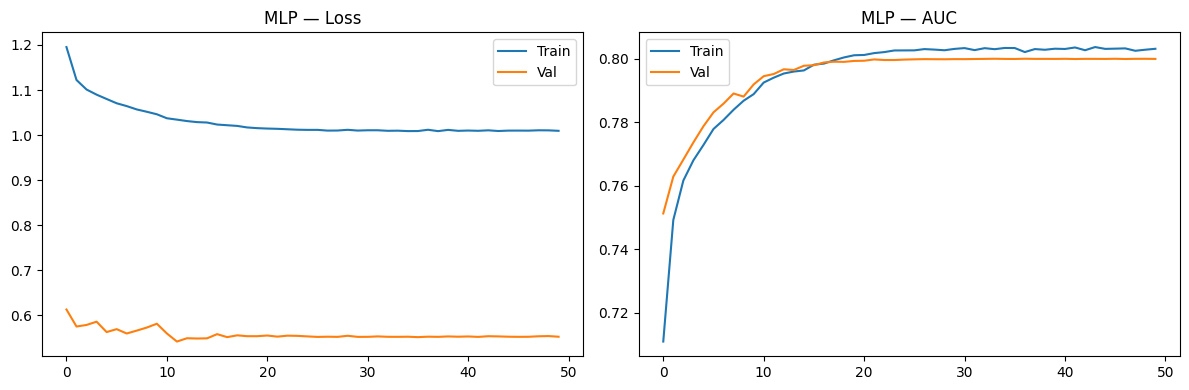

In [14]:
history_mlp = mlp.fit(
    X_train, y_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=get_callbacks(),
    verbose=1
)
plot_training_history(history_mlp, 'MLP')



  MLP
  Accuracy : 0.6745
  Precision: 0.1224
  Recall   : 0.7976
  F1 Score : 0.2122
  ROC-AUC  : 0.8039
              precision    recall  f1-score   support

 Non-default       0.98      0.67      0.79    161444
     Default       0.12      0.80      0.21      9391

    accuracy                           0.67    170835
   macro avg       0.55      0.73      0.50    170835
weighted avg       0.94      0.67      0.76    170835



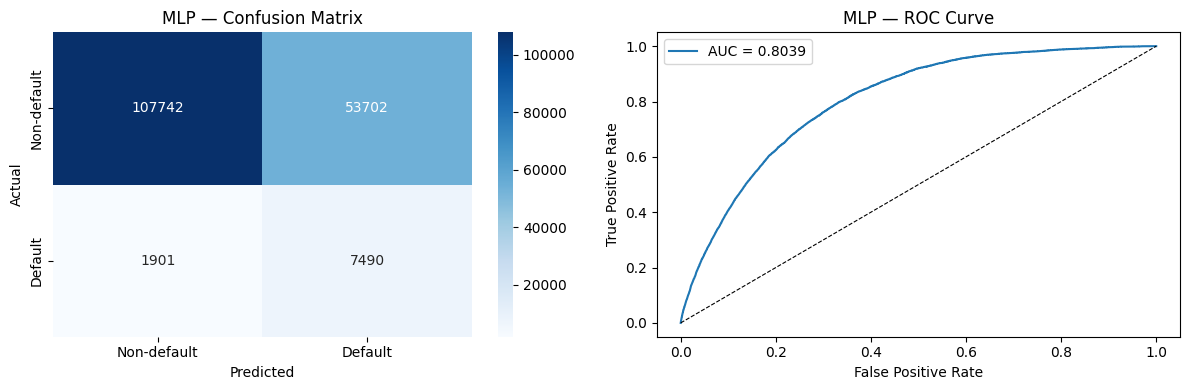

In [15]:
results_mlp = evaluate_model(mlp, X_test, y_test, 'MLP')

---
## 6. Model 2 — TabNet (Attentive Feature Selection)

### Architecture rationale
TabNet (Arik & Pfister, Google Cloud, 2021) is a neural network designed specifically for tabular data. Unlike the MLP — which applies the same weights to all features at every layer — TabNet uses **sequential attention** to select a sparse subset of features at each decision step.

- **Feature transformer** (GLU blocks): processes the masked features through gated linear units, which act as learned non-linear filters. Shared weights across steps help generalisation; step-specific weights allow local adaptation.
- **Attention transformer**: at each step, a softmax mask scores every feature's relevance. A **prior scale** term discourages features from being reused across steps, forcing the model to consider complementary aspects of the data.
- **Multiple decision steps**: each step looks at different features, and their outputs are summed — analogous to an ensemble of focused sub-models.
- **Why it suits this dataset**: your EDA showed that only a handful of features (grade, int_rate, purpose) explain most of the variance. TabNet's sparse feature selection should zero-in on those while ignoring less informative features, improving generalisation on the imbalanced minority class.

In [16]:
def glu_block(x, units, fc_layer=None):
    if fc_layer is None:
        fc_layer = layers.Dense(units * 2, use_bias=False)
    out = fc_layer(x)
    out = layers.BatchNormalization(momentum=0.02)(out)
    # tf.split avoids Lambda closure over 'units', which breaks model serialization
    h1, h2 = tf.split(out, 2, axis=-1)
    return h1 * tf.sigmoid(h2)


def build_tabnet(n_features,
                 n_decision_steps=5,
                 n_a=32,
                 n_d=32,
                 relaxation_factor=1.5):
    inp = Input(shape=(n_features,), name='input')

    shared_fc1 = layers.Dense(n_d * 2, use_bias=False, name='shared_fc1')
    shared_fc2 = layers.Dense(n_d * 2, use_bias=False, name='shared_fc2')

    h = layers.BatchNormalization(momentum=0.02, name='input_bn')(inp)
    prior_scales = layers.Lambda(lambda x: tf.ones_like(x))(inp)

    step_outputs = []

    for step in range(n_decision_steps):
        att = layers.Dense(n_a, use_bias=False, name=f'att_fc_{step}')(h)
        att = layers.BatchNormalization(momentum=0.02, name=f'att_bn_{step}')(att)
        att = layers.Dense(n_features, use_bias=False, name=f'att_out_{step}')(att)
        att = layers.BatchNormalization(momentum=0.02, name=f'att_out_bn_{step}')(att)

        att = att * prior_scales
        att = layers.Softmax(axis=-1)(att)

        prior_scales = prior_scales * (relaxation_factor - att)

        masked_features = att * inp

        x_shared = glu_block(masked_features, n_d, fc_layer=shared_fc1)
        x_shared = glu_block(x_shared,        n_d, fc_layer=shared_fc2)
        x_step   = glu_block(x_shared, n_d,
                              fc_layer=layers.Dense(n_d * 2, use_bias=False,
                                                    name=f'step_fc_{step}'))

        step_out = layers.ReLU()(x_step)
        step_outputs.append(step_out)
        h = x_step

    stacked    = layers.Lambda(lambda tensors: tf.stack(tensors, axis=1))(step_outputs)
    aggregated = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(stacked)

    out = layers.Dense(1, activation='sigmoid', name='output')(aggregated)

    model = Model(inputs=inp, outputs=out, name='TabNet')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=2e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

tabnet = build_tabnet(n_features)
tabnet.summary()


Model: "TabNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 28)]                 0         []                            
                                                                                                  
 input_bn (BatchNormalizati  (None, 28)                   112       ['input[0][0]']               
 on)                                                                                              
                                                                                                  
 att_fc_0 (Dense)            (None, 32)                   896       ['input_bn[0][0]']            
                                                                                                  
 att_bn_0 (BatchNormalizati  (None, 32)                   128       ['att_fc_0[0][0]']       

Epoch 1/50
602/602 [==============================] - 21s 20ms/step - loss: 1.2198 - auc: 0.6984 - precision: 0.0905 - recall: 0.6901 - val_loss: 0.6043 - val_auc: 0.7265 - val_precision: 0.0942 - val_recall: 0.7082 - lr: 0.0020
Epoch 2/50
602/602 [==============================] - 11s 19ms/step - loss: 1.1341 - auc: 0.7440 - precision: 0.1033 - recall: 0.7257 - val_loss: 0.6331 - val_auc: 0.7475 - val_precision: 0.1005 - val_recall: 0.7203 - lr: 0.0020
Epoch 3/50
602/602 [==============================] - 11s 18ms/step - loss: 1.1064 - auc: 0.7589 - precision: 0.1095 - recall: 0.7282 - val_loss: 0.6043 - val_auc: 0.7601 - val_precision: 0.1048 - val_recall: 0.7290 - lr: 0.0020
Epoch 4/50
602/602 [==============================] - 11s 18ms/step - loss: 1.0886 - auc: 0.7678 - precision: 0.1135 - recall: 0.7357 - val_loss: 0.5690 - val_auc: 0.7724 - val_precision: 0.1106 - val_recall: 0.7186 - lr: 0.0020
Epoch 5/50
602/602 [==============================] - 11s 18ms/step - loss: 1.0734 -

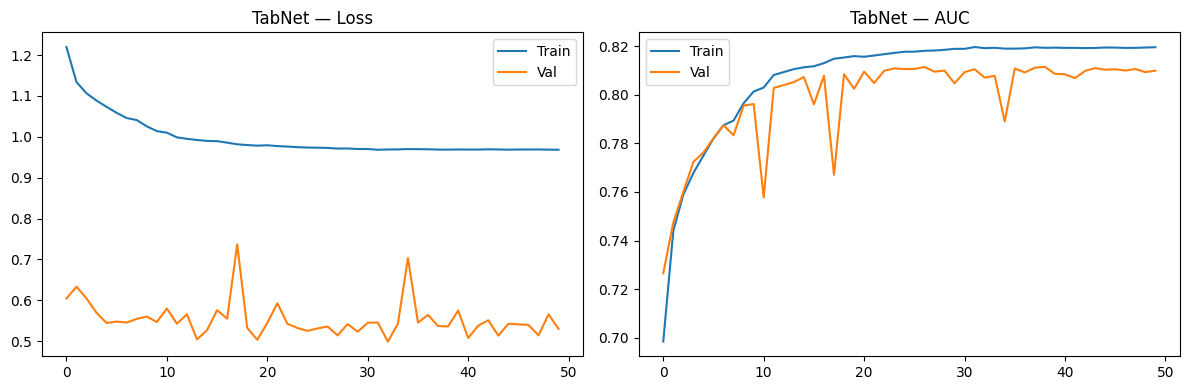

In [17]:
history_tabnet = tabnet.fit(
    X_train, y_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=get_callbacks(),
    verbose=1
)
plot_training_history(history_tabnet, 'TabNet')


  TabNet
  Accuracy : 0.6970
  Precision: 0.1297
  Recall   : 0.7905
  F1 Score : 0.2229
  ROC-AUC  : 0.8130
              precision    recall  f1-score   support

 Non-default       0.98      0.69      0.81    161444
     Default       0.13      0.79      0.22      9391

    accuracy                           0.70    170835
   macro avg       0.56      0.74      0.52    170835
weighted avg       0.94      0.70      0.78    170835



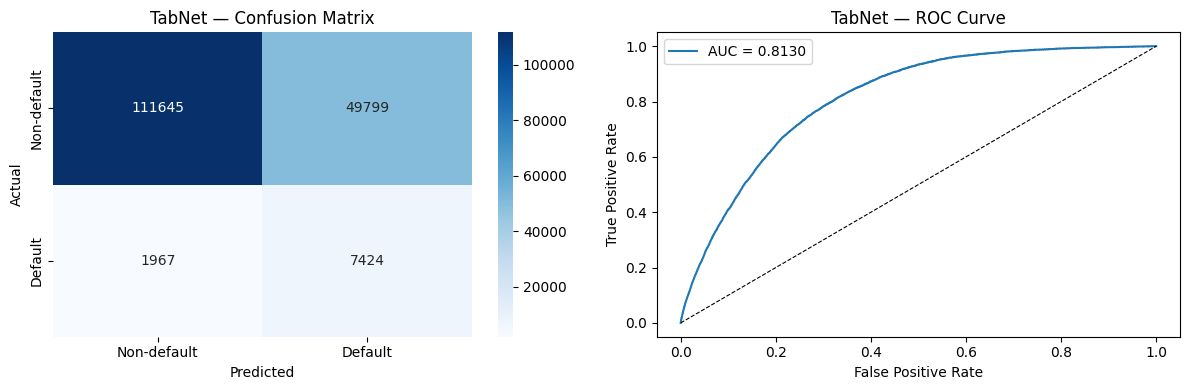

In [18]:
results_tabnet = evaluate_model(tabnet, X_test, y_test, 'TabNet')

---
## 7. Model 3 — ResMLP (Residual MLP with Pre-LayerNorm)

### Architecture rationale
ResMLP applies the **pre-norm residual FFN block** pattern from the Transformer / MLP-Mixer family to tabular data.
Each block normalises its input first, then applies a two-layer feedforward network, then adds the skip connection back.

- **Pre-LayerNorm** (norm → transform → add skip): more stable training than post-norm; the gradient highway through the skip connection is unobstructed.
- **GELU activation**: smoother than ReLU (no dead-neuron problem); the standard choice in BERT, GPT, and MLP-Mixer.
- **LayerNorm vs BatchNorm**: LayerNorm normalises across features per sample (not across the batch), making it robust to small batch sizes and class-imbalanced batches.
- **Why architecturally distinct**: MLP uses BatchNorm + ReLU + no residuals; TabNet uses step-wise sparse attention; ResMLP uses pre-norm residuals + GELU — a different regularisation and optimisation strategy.
- **Width × depth tradeoff**: 4 blocks of hidden dimension 128 — deeper than MLP (3 layers) but narrower, testing whether depth + residuals beats width alone.

In [19]:
def build_resmlp(n_features, n_blocks=4, hidden_dim=128):
    inp = Input(shape=(n_features,), name='input')

    x = layers.Dense(hidden_dim, use_bias=False)(inp)

    for _ in range(n_blocks):
        skip = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(hidden_dim * 2, use_bias=False)(x)
        x = layers.Activation('gelu')(x)
        x = layers.Dense(hidden_dim, use_bias=False)(x)
        x = layers.Dropout(0.1)(x)
        x = layers.Add()([x, skip])

    x = layers.LayerNormalization()(x)
    out = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='ResMLP')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

resmlp = build_resmlp(n_features)
resmlp.summary()

Model: "ResMLP"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, 28)]                 0         []                            
                                                                                                  
 dense_3 (Dense)             (None, 128)                  3584      ['input[0][0]']               
                                                                                                  
 layer_normalization (Layer  (None, 128)                  256       ['dense_3[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 dense_4 (Dense)             (None, 256)                  32768     ['layer_normalization[0][

Epoch 1/50
602/602 [==============================] - 15s 20ms/step - loss: 1.1351 - auc: 0.7422 - precision: 0.1032 - recall: 0.7213 - val_loss: 0.6754 - val_auc: 0.7657 - val_precision: 0.0957 - val_recall: 0.8052 - lr: 0.0010
Epoch 2/50
602/602 [==============================] - 11s 18ms/step - loss: 1.0883 - auc: 0.7692 - precision: 0.1147 - recall: 0.7371 - val_loss: 0.6506 - val_auc: 0.7743 - val_precision: 0.1046 - val_recall: 0.7787 - lr: 0.0010
Epoch 3/50
602/602 [==============================] - 11s 18ms/step - loss: 1.0682 - auc: 0.7796 - precision: 0.1189 - recall: 0.7496 - val_loss: 0.5525 - val_auc: 0.7787 - val_precision: 0.1162 - val_recall: 0.7321 - lr: 0.0010
Epoch 4/50
602/602 [==============================] - 11s 18ms/step - loss: 1.0578 - auc: 0.7846 - precision: 0.1208 - recall: 0.7547 - val_loss: 0.5691 - val_auc: 0.7840 - val_precision: 0.1162 - val_recall: 0.7463 - lr: 0.0010
Epoch 5/50
602/602 [==============================] - 11s 18ms/step - loss: 1.0490 -

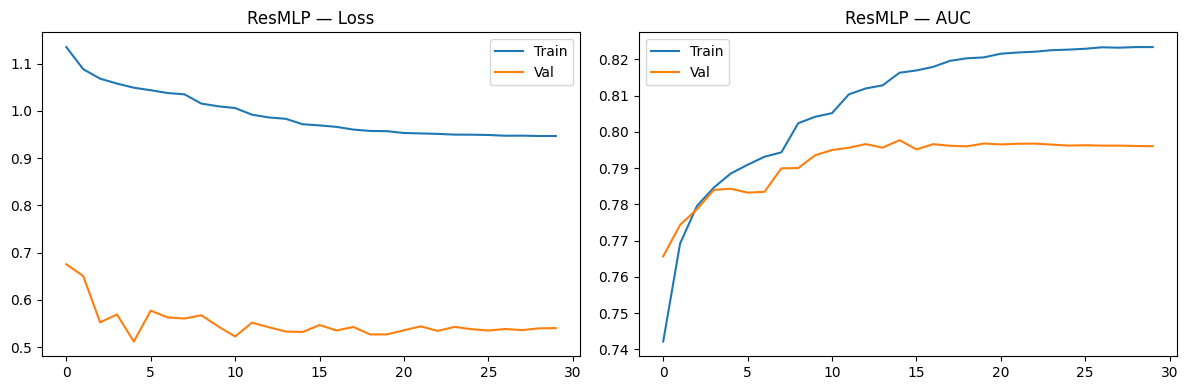

In [20]:
history_resmlp = resmlp.fit(
    X_train, y_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=get_callbacks(),
    verbose=1
)
plot_training_history(history_resmlp, 'ResMLP')


  ResMLP
  Accuracy : 0.6847
  Precision: 0.1244
  Recall   : 0.7842
  F1 Score : 0.2147
  ROC-AUC  : 0.8018
              precision    recall  f1-score   support

 Non-default       0.98      0.68      0.80    161444
     Default       0.12      0.78      0.21      9391

    accuracy                           0.68    170835
   macro avg       0.55      0.73      0.51    170835
weighted avg       0.93      0.68      0.77    170835



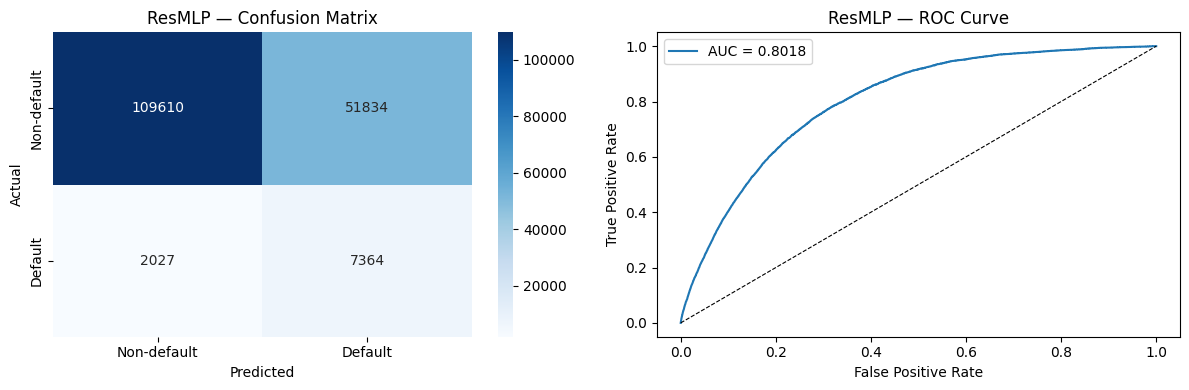

In [21]:
results_resmlp = evaluate_model(resmlp, X_test, y_test, 'ResMLP')

In [22]:
all_results = [results_mlp, results_tabnet, results_resmlp]

summary_data = []
for r in all_results:
    summary_data.append({
        'Model'    : r['model'],
        'Accuracy' : round(float(r['accuracy']), 4),
        'Precision': round(float(r['precision']), 4),
        'Recall'   : round(float(r['recall']), 4),
        'F1'       : round(float(r['f1']), 4),
        'ROC-AUC'  : round(float(r['roc_auc']), 4),
    })

print('\n' + '='*70)
print('  PROCESS TWO — MODEL COMPARISON  (80/20 split)')
print('='*70)

header     = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
col_widths = [15, 12, 12, 12, 12, 12]
print('  ' + '  '.join(f'{h:<{w}}' for h, w in zip(header, col_widths)))
print('  ' + '-' * 66)
for row in summary_data:
    vals = [row['Model'], row['Accuracy'], row['Precision'],
            row['Recall'], row['F1'], row['ROC-AUC']]
    print('  ' + '  '.join(f'{str(v):<{w}}' for v, w in zip(vals, col_widths)))
print('='*70)


  PROCESS TWO — MODEL COMPARISON  (80/20 split)
  Model            Accuracy      Precision     Recall        F1            ROC-AUC     
  ------------------------------------------------------------------
  MLP              0.6745        0.1224        0.7976        0.2122        0.8039      
  TabNet           0.697         0.1297        0.7905        0.2229        0.813       
  ResMLP           0.6847        0.1244        0.7842        0.2147        0.8018      


---
## 8. Cross-Model Comparison

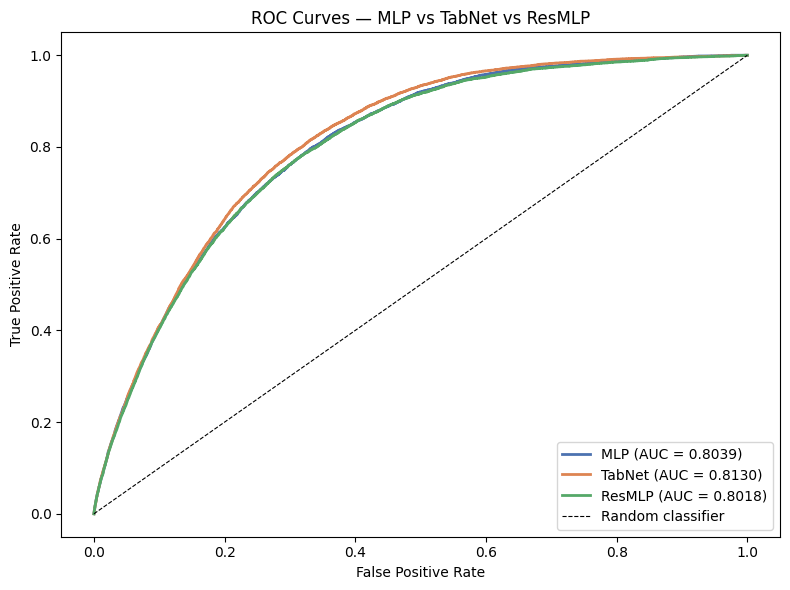

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']
for res, color in zip(all_results, colors):
    ax.plot(res['fpr'], res['tpr'],
            label=f"{res['model']} (AUC = {res['roc_auc']:.4f})",
            color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — MLP vs TabNet vs ResMLP')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

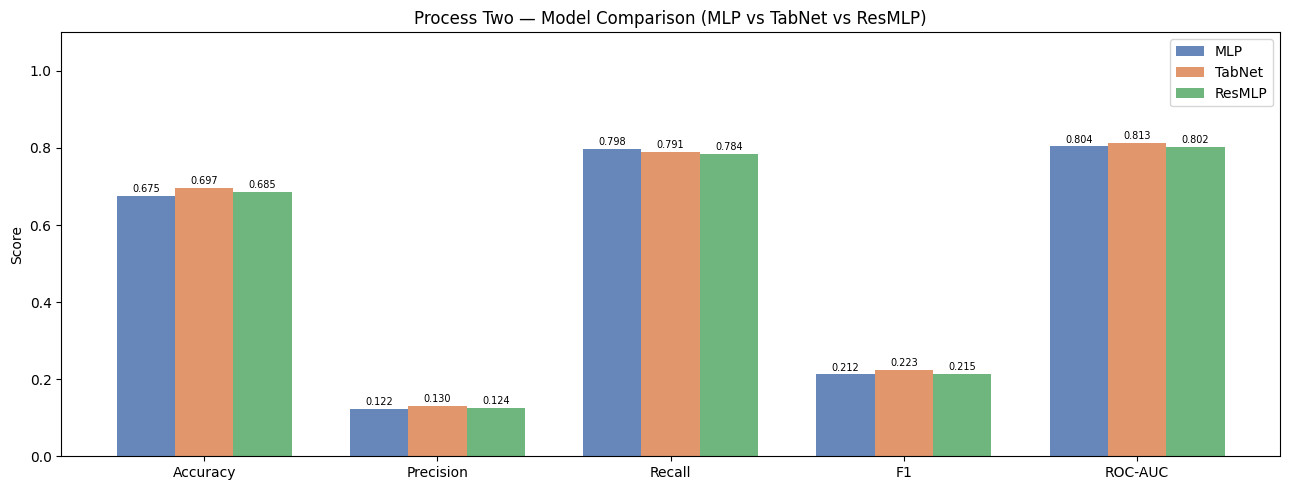

In [24]:
metric_keys   = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x      = np.arange(len(metric_keys))
width  = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (res, color) in enumerate(zip(all_results, colors)):
    vals = [res[k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width,
                  label=res['model'], color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Process Two — Model Comparison (MLP vs TabNet vs ResMLP)')
ax.legend()
plt.tight_layout(); plt.show()

In [26]:
spark.stop()
print("SparkSession stopped.")

SparkSession stopped.
